# Playground for Feature Engineering

- Stephen W. Thomas
- Used for MMA 869, MMAI 869, and GMMA 869

In [1]:
import sklearn
sklearn.__version__

'1.6.1'

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# disable chained assignments
pd.options.mode.chained_assignment = None

# Load Data

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/stepthom/869_course/main/data/GermanCredit.csv')
df['Class'] = df['Class'].map({'Good': 1, 'Bad': 0})
df['Salary'] = df['Amount']
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 63 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Duration                                1000 non-null   int64
 1   Amount                                  1000 non-null   int64
 2   InstallmentRatePercentage               1000 non-null   int64
 3   ResidenceDuration                       1000 non-null   int64
 4   Age                                     1000 non-null   int64
 5   NumberExistingCredits                   1000 non-null   int64
 6   NumberPeopleMaintenance                 1000 non-null   int64
 7   Telephone                               1000 non-null   int64
 8   ForeignWorker                           1000 non-null   int64
 9   Class                                   1000 non-null   int64
 10  CheckingAccountStatus.lt.0              1000 non-null   int64
 11  CheckingAccountSta

,Duration,Amount,InstallmentRatePercentage,ResidenceDuration,Age,NumberExistingCredits,NumberPeopleMaintenance,Telephone,ForeignWorker,Class,...,OtherInstallmentPlans.Stores,OtherInstallmentPlans.None,Housing.Rent,Housing.Own,Housing.ForFree,Job.UnemployedUnskilled,Job.UnskilledResident,Job.SkilledEmployee,Job.Management.SelfEmp.HighlyQualified,Salary
0,6,1169,4,4,67,2,1,0,1,1,...,0,1,0,1,0,0,0,1,0,1169
1,48,5951,2,2,22,1,1,1,1,0,...,0,1,0,1,0,0,0,1,0,5951
2,12,2096,2,3,49,1,2,1,1,1,...,0,1,0,1,0,0,1,0,0,2096
3,42,7882,2,4,45,1,2,1,1,1,...,0,1,0,0,1,0,0,1,0,7882
4,24,4870,3,4,53,2,2,1,1,0,...,0,1,0,0,1,0,0,1,0,4870


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class'], axis=1)
y = df[['Class']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputation

In [5]:
#Create a feature with some missing data
X_train = pd.DataFrame(data={
                         'Age':    [34, np.nan, 29, 28, 53, 25, 32],
                         'Income': [np.nan, 6836, 2319, 1236, 5003, 886, np.nan],
                         })
X_train

#Create a feature with some missing data
X_test = pd.DataFrame(data={
                         'Age': [66, 45, 30],
                         'Income': [np.nan, 6836, 5415],
                         })

X_test

,Age,Income
0,34.0,NaN
1,NaN,6836.0
2,29.0,2319.0
3,28.0,1236.0
4,53.0,5003.0
5,25.0,886.0
6,32.0,NaN


,Age,Income
0,66,NaN
1,45,6836.0
2,30,5415.0


## Simple Imputation

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputer = imputer.fit(X_train[['Age', 'Income']])

X_train[["Age_Imputed", "Income_Imputed"]] = imputer.transform(
    X_train[["Age", "Income"]]
)
X_test[["Age_Imputed", "Income_Imputed"]] = imputer.transform(
    X_test[["Age", "Income"]]
)

In [7]:
X_train[['Age_Imputed', "Income_Imputed"]]

,Age_Imputed,Income_Imputed
0,34.0,3256.0
1,33.5,6836.0
2,29.0,2319.0
3,28.0,1236.0
4,53.0,5003.0
5,25.0,886.0
6,32.0,3256.0


In [8]:
X_test[["Income_Imputed"]]

,Income_Imputed
0,3256.0
1,6836.0
2,5415.0


In [9]:
imputer.statistics_

array([  33.5, 3256. ])

## Multiple/Iterative Imputation

In [10]:
#Create a feature with some missing data
X_train = pd.DataFrame(data={
                         'Age':    [34, np.nan, 29, 28, 53, 25, 32],
                         'Income': [np.nan, 6836, 2319, 1236, 5003, 886, np.nan],
                         })
X_train

#Create a feature with some missing data
X_test = pd.DataFrame(data={
                         'Age': [66, 45, 30],
                         'Income': [np.nan, 6836, 5415],
                         })

X_test

,Age,Income
0,34.0,NaN
1,NaN,6836.0
2,29.0,2319.0
3,28.0,1236.0
4,53.0,5003.0
5,25.0,886.0
6,32.0,NaN


,Age,Income
0,66,NaN
1,45,6836.0
2,30,5415.0


In [11]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

imputer = IterativeImputer(estimator=LinearRegression())
imputer = imputer.fit(X_train)

imputer.transform(X_train)

array([[  34.        , 2417.19505655],
       [  63.94556187, 6836.        ],
       [  29.        , 2319.        ],
       [  28.        , 1236.        ],
       [  53.        , 5003.        ],
       [  25.        ,  886.        ],
       [  32.        , 2127.40799103]])

In [12]:
imputer.transform(X_test)

array([[  66.        , 7053.78810481],
       [  45.        , 6836.        ],
       [  30.        , 5415.        ]])

# Feature Scaling

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class'], axis=1)
y = df[['Class']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Helper function to make a nice-looking histogram

def plot_hist(feature, title):
    plt.figure(figsize=(8, 5));
    plt.hist(feature, bins=20, edgecolor='black', linewidth=1.2);
    plt.title(title, fontsize=20);
    #ax.tick_params(axis='both', which='major', labelsize=18);
    plt.grid(True);

In [15]:
X_train[['Salary', 'Age']].head(10)

,Salary,Age
29,6836,63
535,2319,33
695,1236,50
557,5003,29
836,886,21
596,1442,23
165,2978,32
918,2359,33
495,2996,20
824,3780,35


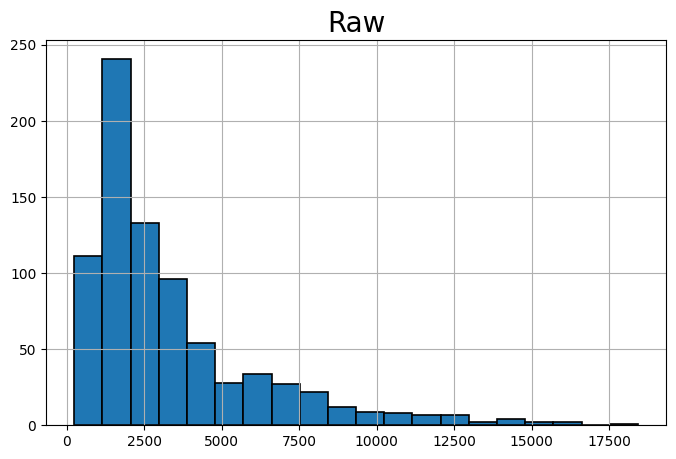

In [16]:
plot_hist(X_train['Salary'], "Raw");

## Standardization

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[['Salary', 'Age']])

X_train[['Salary_Std', 'Age_Std']] = scaler.transform(X_train[['Salary', 'Age']])
X_test[['Salary_Std', 'Age_Std']] = scaler.transform(X_test[['Salary', 'Age']])

StandardScaler()

In [18]:
X_train[['Salary_Std', 'Age_Std']].head(10)

,Salary_Std,Age_Std
29,1.199912,2.406187
535,-0.359630,-0.224364
695,-0.733547,1.266282
557,0.567050,-0.575104
836,-0.854388,-1.276585
596,-0.662423,-1.101215
165,-0.132103,-0.312049
918,-0.345819,-0.224364
495,-0.125888,-1.364270
824,0.144796,-0.048994


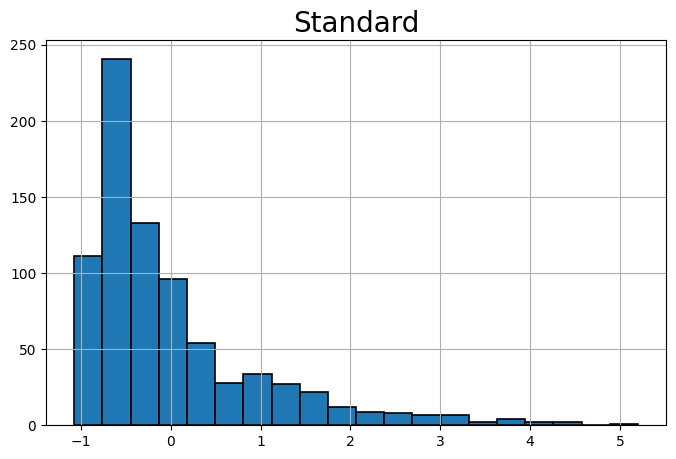

In [19]:
plot_hist(X_train['Salary_Std'], "Standard");

## MinMax

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train[['Salary']])

X_train['Salary_MinMax'] = scaler.transform(X_train[['Salary']])
X_test['Salary_MinMax'] = scaler.transform(X_test[['Salary']])

MinMaxScaler()

In [21]:
X_train[['Salary_MinMax']].head(10)

,Salary_MinMax
29,0.362386
535,0.113844
695,0.054253
557,0.261527
836,0.034995
596,0.065588
165,0.150105
918,0.116045
495,0.151095
824,0.194234


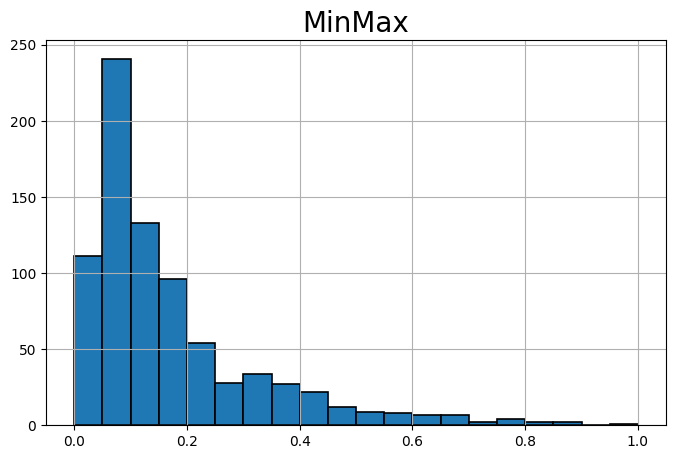

In [22]:
plot_hist(X_train['Salary_MinMax'], "MinMax");

## Log

In [23]:
from sklearn.preprocessing import FunctionTransformer

scaler = FunctionTransformer(np.log1p, validate=True)
scaler.fit(X_train[['Salary']])
X_train['Salary_Log'] = scaler.transform(X_train[['Salary']])
X_test['Salary_Log'] = scaler.transform(X_test[['Salary']])

FunctionTransformer(func=<ufunc 'log1p'>, validate=True)

In [24]:
X_train[['Salary_Log']].head(10)

,Salary_Log
29,8.830104
535,7.749322
695,7.120444
557,8.517993
836,6.787845
596,7.274480
165,7.999343
918,7.766417
495,8.005367
824,8.237744


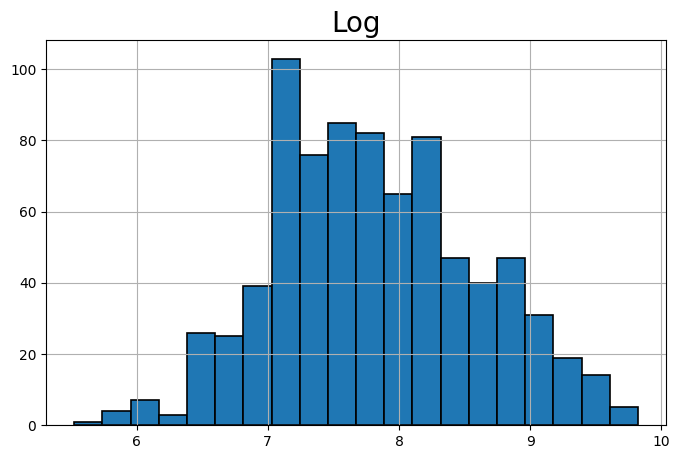

In [25]:
plot_hist(X_train['Salary_Log'], "Log");

## Box-Cox

In [26]:
from sklearn.preprocessing import PowerTransformer

scaler = PowerTransformer(method='box-cox')
scaler.fit(X_train[['Salary']])
X_train['Salary_BoxCox'] = scaler.transform(X_train[['Salary']])
X_test['Salary_BoxCox'] = scaler.transform(X_test[['Salary']])

PowerTransformer(method='box-cox')

In [27]:
X_train[['Salary_BoxCox']].head(10)

,Salary_BoxCox
29,1.291730
535,-0.054503
695,-0.893962
557,0.914991
836,-1.355653
596,-0.684355
165,0.267494
918,-0.032279
495,0.275172
824,0.568502


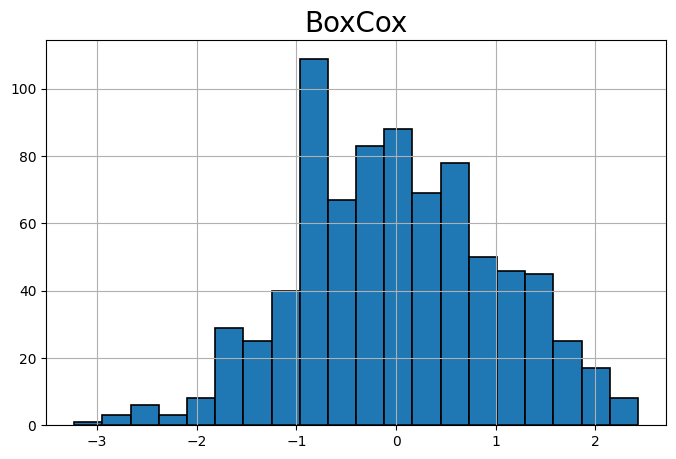

In [28]:
plot_hist(X_train['Salary_BoxCox'], "BoxCox");

## Yeo-Johnson

In [29]:
from sklearn.preprocessing import PowerTransformer

scaler = PowerTransformer(method='yeo-johnson')
scaler.fit(X_train[['Salary']])
X_train['Salary_YeoJohnson'] = scaler.transform(X_train[['Salary']])

PowerTransformer()

In [30]:
X_train[['Salary_YeoJohnson']].head(10)

,Salary_YeoJohnson
29,1.291774
535,-0.054483
695,-0.894055
557,0.915073
836,-1.355755
596,-0.684425
165,0.267553
918,-0.032256
495,0.275232
824,0.568584


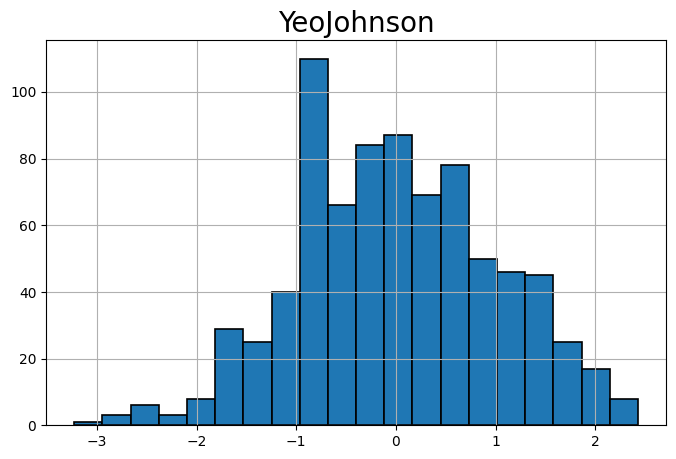

In [31]:
plot_hist(X_train['Salary_YeoJohnson'], "YeoJohnson");

## Binning

In [32]:
# TODO

# Categorical Encoding


We will create a little fake dataset to help illustrate how the different encoding schemes work.

In [33]:
train_df = pd.DataFrame(data={

                          # An ID and two categorical features to play around with
                         'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                         'Province': ['ON', 'QB', 'AB', 'ON', 'ON', 'BC', 'BC', 'QB', 'AB', 'ON', 'QB', 'AB', 'ON', 'ON', 'ON'],
                         'Income': ['Low', 'Low', 'Low', 'Low', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'High', 'High', 'High', 'High', 'High'],

                         # We'll make one binary target
                         'Default': [0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1],

                         # And one multi-label target (for testing below)
                         'Risk': [1, 1, 2, 2,    0, 0, 1, 1, 1, 2,    0, 0, 0, 1, 1],
                         })

train_df
X_train = train_df.drop(['Default', 'Risk'], axis=1)
y_train1 = train_df['Default']
y_train2 = train_df['Risk']

,ID,Province,Income,Default,Risk
0,1,ON,Low,0,1
1,2,QB,Low,1,1
2,3,AB,Low,1,2
3,4,ON,Low,1,2
4,5,ON,Medium,0,0
5,6,BC,Medium,0,0
6,7,BC,Medium,0,1
7,8,QB,Medium,1,1
8,9,AB,Medium,1,1
9,10,ON,Medium,1,2


In [34]:
X_test = pd.DataFrame(data={'ID': [101, 102, 103, 104],
                         'Province': ['ON', 'QB', 'AB', 'ON'],
                         'Income': ['Low', 'Low', 'Medium', 'High'],
                             })

X_test

,ID,Province,Income
0,101,ON,Low
1,102,QB,Low
2,103,AB,Medium
3,104,ON,High


## One Hot Encoding

In [35]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc = enc.fit(X_train[['Province']])

enc.transform(X_train[['Province']])

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

In [36]:
# If you want it back into the original pandas dataframe...

_ohe_array = enc.transform(X_train[['Province']])
_ohe_names = enc.get_feature_names_out()
print(_ohe_names)
for i in range(_ohe_array.shape[1]):
  X_train[_ohe_names[i]] = _ohe_array[:,i]

X_train

['Province_AB' 'Province_BC' 'Province_ON' 'Province_QB']


,ID,Province,Income,Province_AB,Province_BC,Province_ON,Province_QB
0,1,ON,Low,0.0,0.0,1.0,0.0
1,2,QB,Low,0.0,0.0,0.0,1.0
2,3,AB,Low,1.0,0.0,0.0,0.0
3,4,ON,Low,0.0,0.0,1.0,0.0
4,5,ON,Medium,0.0,0.0,1.0,0.0
5,6,BC,Medium,0.0,1.0,0.0,0.0
6,7,BC,Medium,0.0,1.0,0.0,0.0
7,8,QB,Medium,0.0,0.0,0.0,1.0
8,9,AB,Medium,1.0,0.0,0.0,0.0
9,10,ON,Medium,0.0,0.0,1.0,0.0


In [37]:
enc.transform(X_test[['Province']])

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]])

## Another Example

In [38]:
X = pd.DataFrame({'Province': ['ON', 'QB', 'AB', 'ON', 'ON', 'BC', 'QB']})
enc = OneHotEncoder(sparse_output=False,
                    min_frequency=2,
                    max_categories=10,
                    handle_unknown="infrequent_if_exist")
enc = enc.fit(X)
X[enc.get_feature_names_out()] = enc.transform(X)

X

,Province,Province_ON,Province_QB,Province_infrequent_sklearn
0,ON,1.0,0.0,0.0
1,QB,0.0,1.0,0.0
2,AB,0.0,0.0,1.0
3,ON,1.0,0.0,0.0
4,ON,1.0,0.0,0.0
5,BC,0.0,0.0,1.0
6,QB,0.0,1.0,0.0


## Ordinal Encoding

In [39]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
enc = enc.fit(X_train[['Income']])

X_train['Income_Ord'] = enc.transform(X_train[['Income']])

In [40]:
X_train

,ID,Province,Income,Province_AB,Province_BC,Province_ON,Province_QB,Income_Ord
0,1,ON,Low,0.0,0.0,1.0,0.0,1.0
1,2,QB,Low,0.0,0.0,0.0,1.0,1.0
2,3,AB,Low,1.0,0.0,0.0,0.0,1.0
3,4,ON,Low,0.0,0.0,1.0,0.0,1.0
4,5,ON,Medium,0.0,0.0,1.0,0.0,2.0
5,6,BC,Medium,0.0,1.0,0.0,0.0,2.0
6,7,BC,Medium,0.0,1.0,0.0,0.0,2.0
7,8,QB,Medium,0.0,0.0,0.0,1.0,2.0
8,9,AB,Medium,1.0,0.0,0.0,0.0,2.0
9,10,ON,Medium,0.0,0.0,1.0,0.0,2.0


In [41]:
enc.categories_

[array(['High', 'Low', 'Medium'], dtype=object)]

In [42]:
enc.transform(X_test[['Income']])

array([[1.],
       [1.],
       [2.],
       [0.]])

We could also force the categories to be in a certain order:

In [43]:
enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
enc = enc.fit(X_train[['Income']])

enc.transform(X_train[['Income']])

array([[0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.]])

In [44]:
enc.categories_

[array(['Low', 'Medium', 'High'], dtype=object)]

In [45]:
enc.transform(X_test[['Income']])

array([[0.],
       [0.],
       [1.],
       [2.]])

## Another example

In [46]:
X = pd.DataFrame({'Temp': ['cold', 'warm', 'cold', 'hot', 'cold', 'warm',]})
# Define from lowest to highest
enc = OrdinalEncoder(categories=[['cold', 'warm', 'hot']])
enc = enc.fit(X)
X['Temp_encoded'] = enc.transform(X)

X

,Temp,Temp_encoded
0,cold,0.0
1,warm,1.0
2,cold,0.0
3,hot,2.0
4,cold,0.0
5,warm,1.0


## Target Encoding

In [47]:
train_df

,ID,Province,Income,Default,Risk
0,1,ON,Low,0,1
1,2,QB,Low,1,1
2,3,AB,Low,1,2
3,4,ON,Low,1,2
4,5,ON,Medium,0,0
5,6,BC,Medium,0,0
6,7,BC,Medium,0,1
7,8,QB,Medium,1,1
8,9,AB,Medium,1,1
9,10,ON,Medium,1,2


In [48]:
X = pd.DataFrame({"Income": ['Low', 'Low', 'Low', 'Low', 'Low', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium']})
y  = pd.Series([0, 0, 0, 1, 1, 1, 1, 1, 1, 0])

from sklearn.preprocessing import TargetEncoder

enc = TargetEncoder(smooth=0, random_state=77, cv=3)
X["Income_encoded"] = enc.fit_transform(X, y)


X

,Income,Income_encoded
0,Low,0.500000
1,Low,0.333333
2,Low,0.500000
3,Low,0.333333
4,Low,0.500000
5,Medium,1.000000
6,Medium,1.000000
7,Medium,0.750000
8,Medium,0.750000
9,Medium,1.000000


In [49]:
enc = TargetEncoder()
enc.fit_transform(train_df[['Income']], y_train1)

array([[1.        ],
       [0.60827251],
       [0.62857143],
       [0.60827251],
       [0.58389262],
       [0.5       ],
       [0.48295455],
       [0.41610738],
       [0.48295455],
       [0.5       ],
       [0.28947368],
       [0.28947368],
       [0.28947368],
       [0.        ],
       [0.        ]])

## Target Encoding with A Multi-label Target

In [50]:
enc = TargetEncoder()
enc.fit_transform(X_train[['Income']], y_train2.tolist())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


array([[0.        , 0.35279805, 0.54867257],
       [0.        , 0.35279805, 0.54867257],
       [0.        , 0.62857143, 0.27536232],
       [0.        , 0.62857143, 0.27536232],
       [0.21678322, 0.58389262, 0.19375813],
       [0.26451613, 0.5       , 0.22897196],
       [0.26451613, 0.5       , 0.22897196],
       [0.46341463, 0.5       , 0.        ],
       [0.38815789, 0.40274862, 0.20728929],
       [0.46341463, 0.5       , 0.        ],
       [0.58333333, 0.35279805, 0.        ],
       [0.46341463, 0.48295455, 0.        ],
       [0.46341463, 0.5       , 0.        ],
       [0.58333333, 0.35279805, 0.        ],
       [0.67741935, 0.28947368, 0.        ]])

# Aggregations

In [51]:
pip install featuretools

In [52]:
import featuretools as ft

# Let's load a different kind of dataset - one that has lots of transactions

es = ft.demo.load_mock_customer(return_entityset=True)
es

/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
/usr/local/lib/python3.12/dist-packages/woodwork/type_sys/utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. 

Entityset: transactions
  DataFrames:
    transactions [Rows: 500, Columns: 6]
    products [Rows: 5, Columns: 3]
    sessions [Rows: 35, Columns: 5]
    customers [Rows: 5, Columns: 5]
  Relationships:
    transactions.product_id -> products.product_id
    transactions.session_id -> sessions.session_id
    sessions.customer_id -> customers.customer_id

In [53]:
es["transactions"].head(30)

,transaction_id,session_id,transaction_time,product_id,amount,_ft_last_time
2,2,1,2014-01-01 00:00:00,5,127.64,2014-01-01 00:00:00
495,495,1,2014-01-01 00:01:05,2,109.48,2014-01-01 00:01:05
341,341,1,2014-01-01 00:02:10,3,95.06,2014-01-01 00:02:10
308,308,1,2014-01-01 00:03:15,4,78.92,2014-01-01 00:03:15
271,271,1,2014-01-01 00:04:20,3,31.54,2014-01-01 00:04:20
438,438,1,2014-01-01 00:05:25,3,23.76,2014-01-01 00:05:25
298,298,1,2014-01-01 00:06:30,3,43.63,2014-01-01 00:06:30
371,371,1,2014-01-01 00:07:35,4,42.27,2014-01-01 00:07:35
158,158,1,2014-01-01 00:08:40,3,47.68,2014-01-01 00:08:40
245,245,1,2014-01-01 00:09:45,5,57.39,2014-01-01 00:09:45


In [54]:
feature_matrix, features = ft.dfs(entityset=es,
                                   target_dataframe_name="customers",
                                   verbose=True)
feature_matrix

Built 75 features
Elapsed: 00:00 | Progress:  84%|████████▍ 

/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x7dc697b5b7e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x7dc697b5b920> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  ).agg(to_agg)
/usr/local/lib/python3.12/dist-packages/featuretools/computational_backends/feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x7dc697b5af20> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable wil

Elapsed: 00:00 | Progress: 100%|██████████


,zip_code,COUNT(sessions),MODE(sessions.device),NUM_UNIQUE(sessions.device),COUNT(transactions),MAX(transactions.amount),MEAN(transactions.amount),MIN(transactions.amount),MODE(transactions.product_id),NUM_UNIQUE(transactions.product_id),...,STD(sessions.SKEW(transactions.amount)),STD(sessions.SUM(transactions.amount)),SUM(sessions.MAX(transactions.amount)),SUM(sessions.MEAN(transactions.amount)),SUM(sessions.MIN(transactions.amount)),SUM(sessions.NUM_UNIQUE(transactions.product_id)),SUM(sessions.SKEW(transactions.amount)),SUM(sessions.STD(transactions.amount)),MODE(transactions.sessions.device),NUM_UNIQUE(transactions.sessions.device)
customer_id,,,,,,,,,,,,,,,,,,,,,
5,60091,6,mobile,3,79,149.02,80.375443,7.55,5,5,...,0.415426,402.775486,839.76,472.231119,86.49,30.0,0.014384,259.873954,mobile,3
4,60091,8,mobile,3,109,149.95,80.070459,5.73,2,5,...,0.387884,235.992478,1157.99,649.657515,131.51,37.0,0.002764,356.125829,mobile,3
1,60091,8,mobile,3,126,139.43,71.631905,5.81,4,5,...,0.589386,279.510713,1057.97,582.193117,78.59,40.0,-0.476122,312.745952,mobile,3
3,13244,6,desktop,3,93,149.15,67.060430,5.89,1,5,...,0.429374,219.021420,847.63,405.237462,66.21,29.0,2.286086,257.299895,desktop,3
2,13244,7,desktop,3,93,146.81,77.422366,8.73,4,5,...,0.509798,251.609234,931.63,548.905851,154.60,35.0,-0.277640,258.700528,desktop,3


In [55]:
list(feature_matrix)

['zip_code',
 'COUNT(sessions)',
 'MODE(sessions.device)',
 'NUM_UNIQUE(sessions.device)',
 'COUNT(transactions)',
 'MAX(transactions.amount)',
 'MEAN(transactions.amount)',
 'MIN(transactions.amount)',
 'MODE(transactions.product_id)',
 'NUM_UNIQUE(transactions.product_id)',
 'SKEW(transactions.amount)',
 'STD(transactions.amount)',
 'SUM(transactions.amount)',
 'DAY(birthday)',
 'DAY(join_date)',
 'MONTH(birthday)',
 'MONTH(join_date)',
 'WEEKDAY(birthday)',
 'WEEKDAY(join_date)',
 'YEAR(birthday)',
 'YEAR(join_date)',
 'MAX(sessions.COUNT(transactions))',
 'MAX(sessions.MEAN(transactions.amount))',
 'MAX(sessions.MIN(transactions.amount))',
 'MAX(sessions.NUM_UNIQUE(transactions.product_id))',
 'MAX(sessions.SKEW(transactions.amount))',
 'MAX(sessions.STD(transactions.amount))',
 'MAX(sessions.SUM(transactions.amount))',
 'MEAN(sessions.COUNT(transactions))',
 'MEAN(sessions.MAX(transactions.amount))',
 'MEAN(sessions.MEAN(transactions.amount))',
 'MEAN(sessions.MIN(transactions.amo

In [56]:
ft.list_primitives()

,name,type,description,valid_inputs,return_type
0,num_zero_crossings,aggregation,Determines the number of times a list crosses ...,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = Integer) (Semant...
1,median_count,aggregation,Calculates the number of occurrences of the me...,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = IntegerNullable)...
2,date_first_event,aggregation,Determines the first datetime from a list of d...,<ColumnSchema (Logical Type = Datetime) (Seman...,<ColumnSchema (Logical Type = Datetime)>
3,max,aggregation,"Calculates the highest value, ignoring `NaN` v...",<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
4,is_unique,aggregation,Determines whether or not a series of discrete...,<ColumnSchema (Semantic Tags = ['category'])>,<ColumnSchema (Logical Type = BooleanNullable)>
...,...,...,...,...,...
198,tangent,transform,Computes the tangent of a number.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = Double) (Semanti...
199,one_digit_postal_code,transform,Returns the one digit prefix of a given postal...,<ColumnSchema (Logical Type = PostalCode)>,<ColumnSchema (Logical Type = Categorical) (Se...
200,expanding_trend,transform,Computes the expanding trend for events over a...,<ColumnSchema (Logical Type = Datetime) (Seman...,<ColumnSchema (Logical Type = Double) (Semanti...
201,natural_logarithm,transform,Computes the natural logarithm of a number.,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = Double) (Semanti...
